# LeetCode #26: Remove Duplicates from Sorted Array

https://leetcode.com/problems/remove-duplicates-from-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(n)$ |
| **Two Pointers** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Collect unique elements into a separate array (or set), then copy them back. Same linear time as the optimal approach but allocates $O(n)$ extra space for the temporary buffer.

### Optimal: Two Pointers ★
Keep a write pointer `k` starting at 1. Scan left-to-right; whenever the current element differs from its predecessor, write it to `nums[k]` and advance `k`. One pass, zero extra allocations.

**Why this is better than Brute Force:** Eliminates the auxiliary array entirely by exploiting the sorted order — identical elements are always adjacent, so a single comparison per step is enough to filter them in place.

**Constraints:**
* 1 ≤ nums.length ≤ 3 × 10⁴
* −100 ≤ nums[i] ≤ 100
* nums is sorted in non-decreasing order

## Solutions

### C#

In [ ]:
public class Solution {
    public int RemoveDuplicates(int[] nums) {
        int k = 1;
        for (int i = 1; i < nums.Length; i++) {
            // Write current element only when it breaks the run of duplicates
            if (nums[i] != nums[i - 1])
                nums[k++] = nums[i];
        }
        return k;
    }
}

### Python

In [ ]:
class Solution:
    def removeDuplicates(self, nums: List[int]) -> int:
        k = 1
        for i in range(1, len(nums)):
            # Write current element only when it breaks the run of duplicates
            if nums[i] != nums[i - 1]:
                nums[k] = nums[i]
                k += 1
        return k

### Go

In [ ]:
func removeDuplicates(nums []int) int {
    k := 1
    for i := 1; i < len(nums); i++ {
        // Write current element only when it breaks the run of duplicates
        if nums[i] != nums[i-1] {
            nums[k] = nums[i]
            k++
        }
    }
    return k
}

### Rust

In [ ]:
pub fn remove_duplicates(nums: &mut Vec<i32>) -> i32 {
    let mut k = 1usize;
    for i in 1..nums.len() {
        // Write current element only when it breaks the run of duplicates
        if nums[i] != nums[i - 1] {
            nums[k] = nums[i];
            k += 1;
        }
    }
    k as i32
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 1, 2]
i=1: nums[1]==nums[0] → skip. i=2: nums[2]=2 ≠ nums[1]=1 → nums[1]=2, k=2. Array prefix: [1, 2]. Return **2**.

**2. Slightly Complex**
**Input:** nums = [0, 0, 1, 1, 1, 2, 2, 3, 3, 4]
Write pointer k advances only on value changes: at 1 (i=2), 2 (i=5), 3 (i=7), 4 (i=9) → five unique values written. Return **5**.

**3. Edge Case: Time Factor — long run of identical elements**
**Input:** nums = [7, 7, 7, …, 7, 8]  (n−1 sevens followed by one 8)
The loop visits all n−1 intermediate elements without writing; only at i=n−1 does k advance to 2. One write regardless of how long the duplicate run is — $O(n)$ reads, $O(1)$ writes.

**4. Edge Case: Space Factor — no duplicates at all**
**Input:** nums = [1, 2, 3, 4, 5]
Every element triggers a write: nums[k++] = nums[i] for each i. k climbs to n with zero extra allocations — the write pointer just shadows the read pointer one step behind.

**5. Almost-Impossible but Plausible — single element**
**Input:** nums = [42]
The loop body never executes (range 1..1 is empty). k stays 1. Return **1** — correct with no iterations.

## Infographic

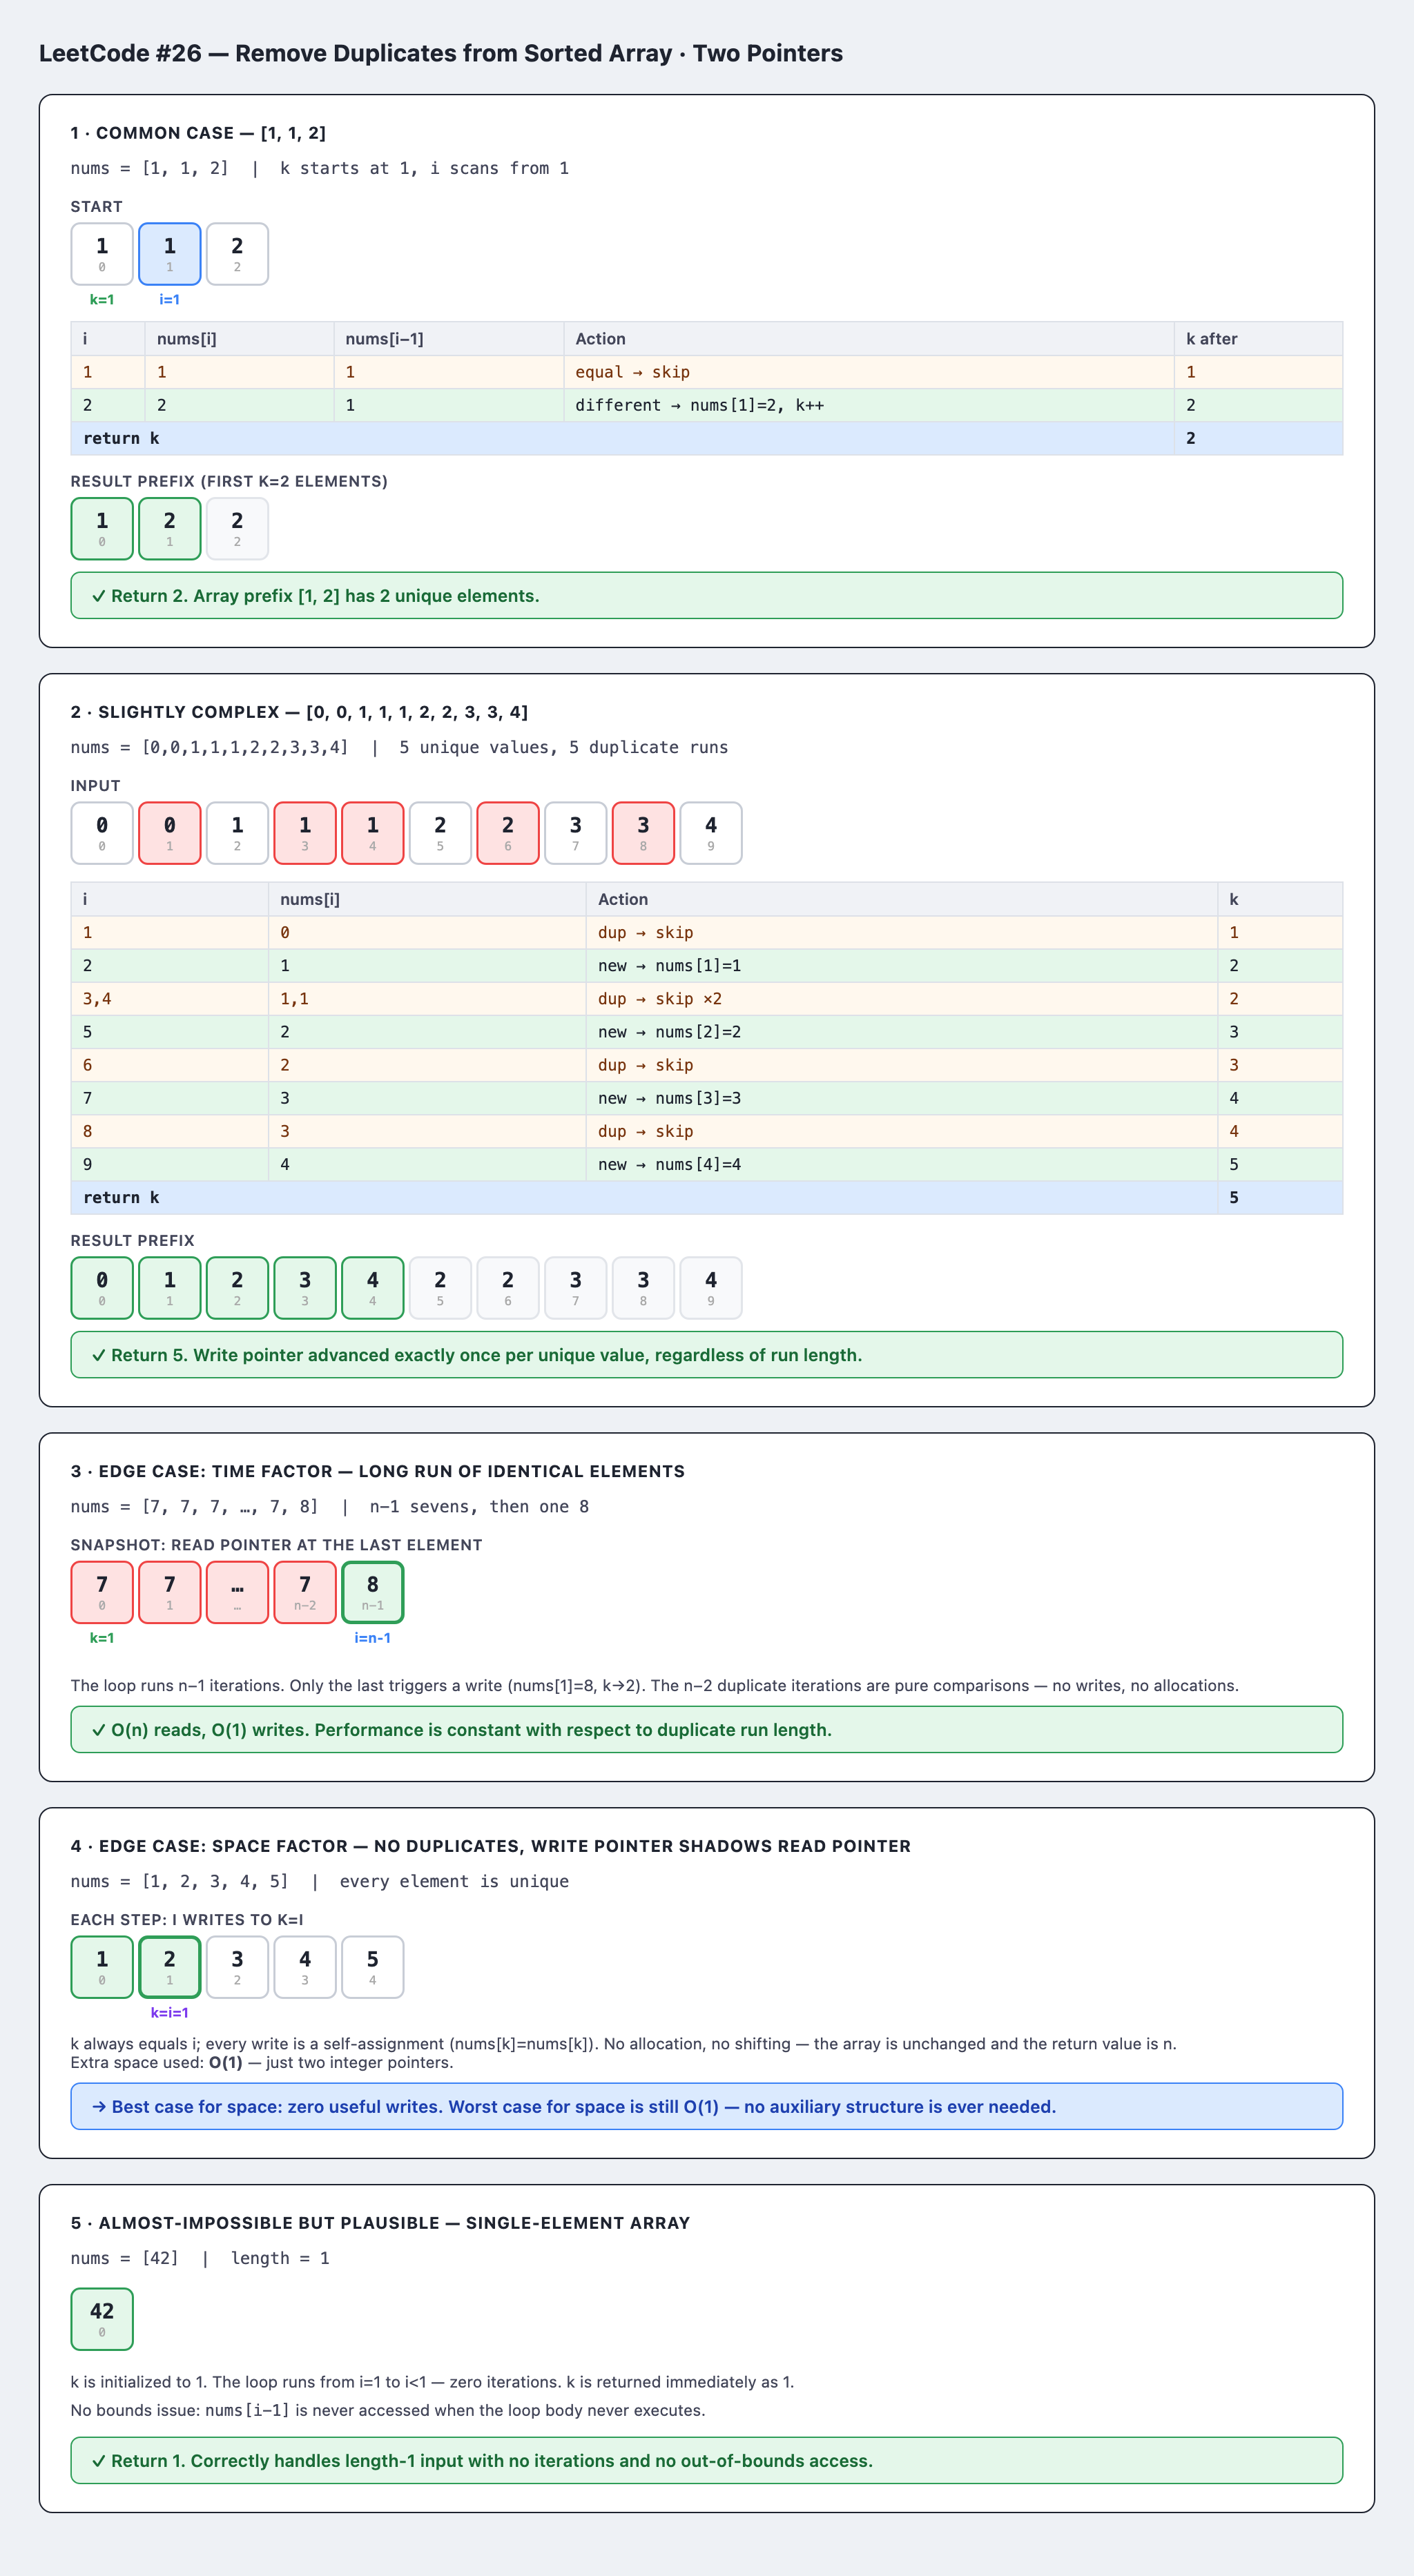